In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Verify the path (Replace 'My Dataset' with your folder name)
import os
data_path = '/content/drive/MyDrive/drone'
print("Data is ready at:", os.listdir(data_path))

Mounted at /content/drive
Data is ready at: ['README.dataset.txt', 'README.roboflow.txt', 'valid', 'test', 'train', 'data.yaml']


In [ ]:
!pip install ultralytics
from ultralytics import YOLO

model = YOLO('yolo26n.yaml')

# Training
model.train(
    data=f'{data_path}/data.yaml',
    epochs=100,
    imgsz=640,
    project='/content/drive/MyDrive/drone_results26', # Results saved here permanently
    name='drone_detection_v1'
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/drone/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=drone_detection_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7eb260046420>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

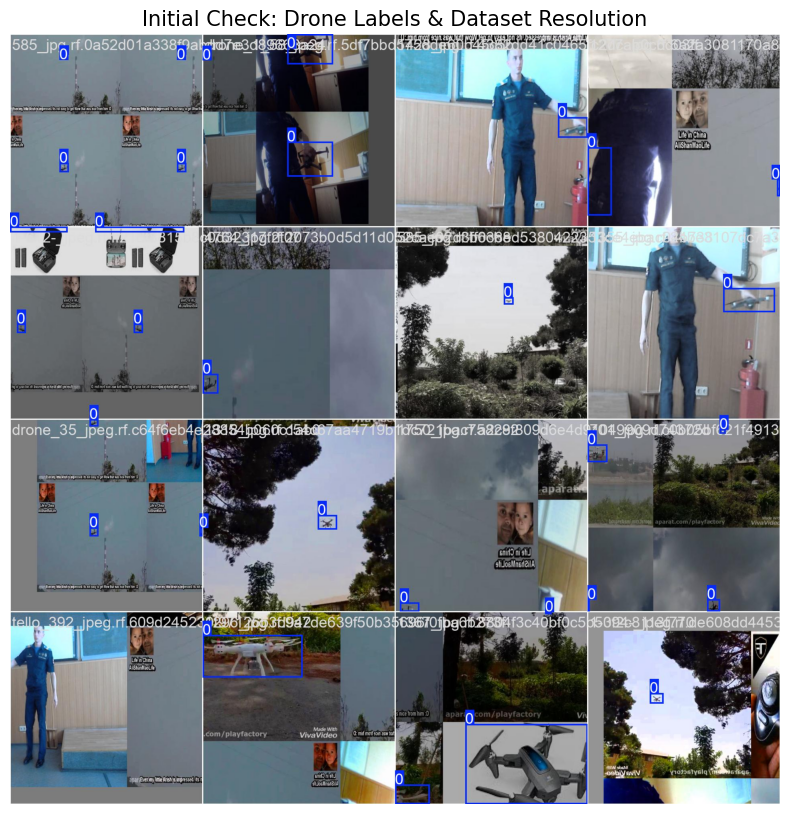

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Path to the first batch generated by YOLO
check_path = '/content/drive/MyDrive/drone_results26/drone_detection_v1/train_batch0.jpg'

if os.path.exists(check_path):
    plt.figure(figsize=(15, 10))
    img = mpimg.imread(check_path)
    plt.imshow(img)
    plt.title("Initial Check: Drone Labels & Dataset Resolution", fontsize=15)
    plt.axis('off')
    plt.show()
else:
    print("Epoch 1 is still running. Wait a moment and try again!")

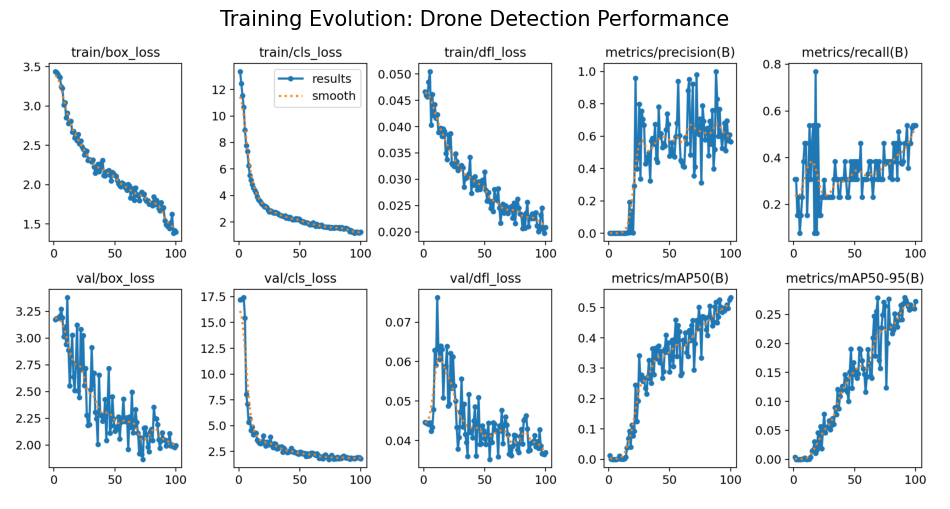

In [ ]:
results_plot = '/content/drive/MyDrive/drone_results26/drone_detection_v1/results.png'

if os.path.exists(results_plot):
    plt.figure(figsize=(12, 8))
    img = mpimg.imread(results_plot)
    plt.imshow(img)
    plt.title("Training Evolution: Drone Detection Performance", fontsize=15)
    plt.axis('off')
    plt.show()
else:
    print("Training in progress... results.png is generated after the first few epochs.")


image 1/3 /content/drive/MyDrive/drone/test/images/1-585-_jpeg.rf.56966f24bef88c19be94a8c4b560aef6.jpg: 640x640 1 drone, 8.7ms
image 2/3 /content/drive/MyDrive/drone/test/images/drone_1_55_jpeg.rf.adaa0d8f1f91b3c9518bedbf483f6da1.jpg: 640x640 (no detections), 8.8ms
image 3/3 /content/drive/MyDrive/drone/test/images/drone_1_75_jpeg.rf.d543e294e793becffb4e9efd82d67e09.jpg: 640x640 1 drone, 7.9ms
Speed: 1.6ms preprocess, 8.5ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2


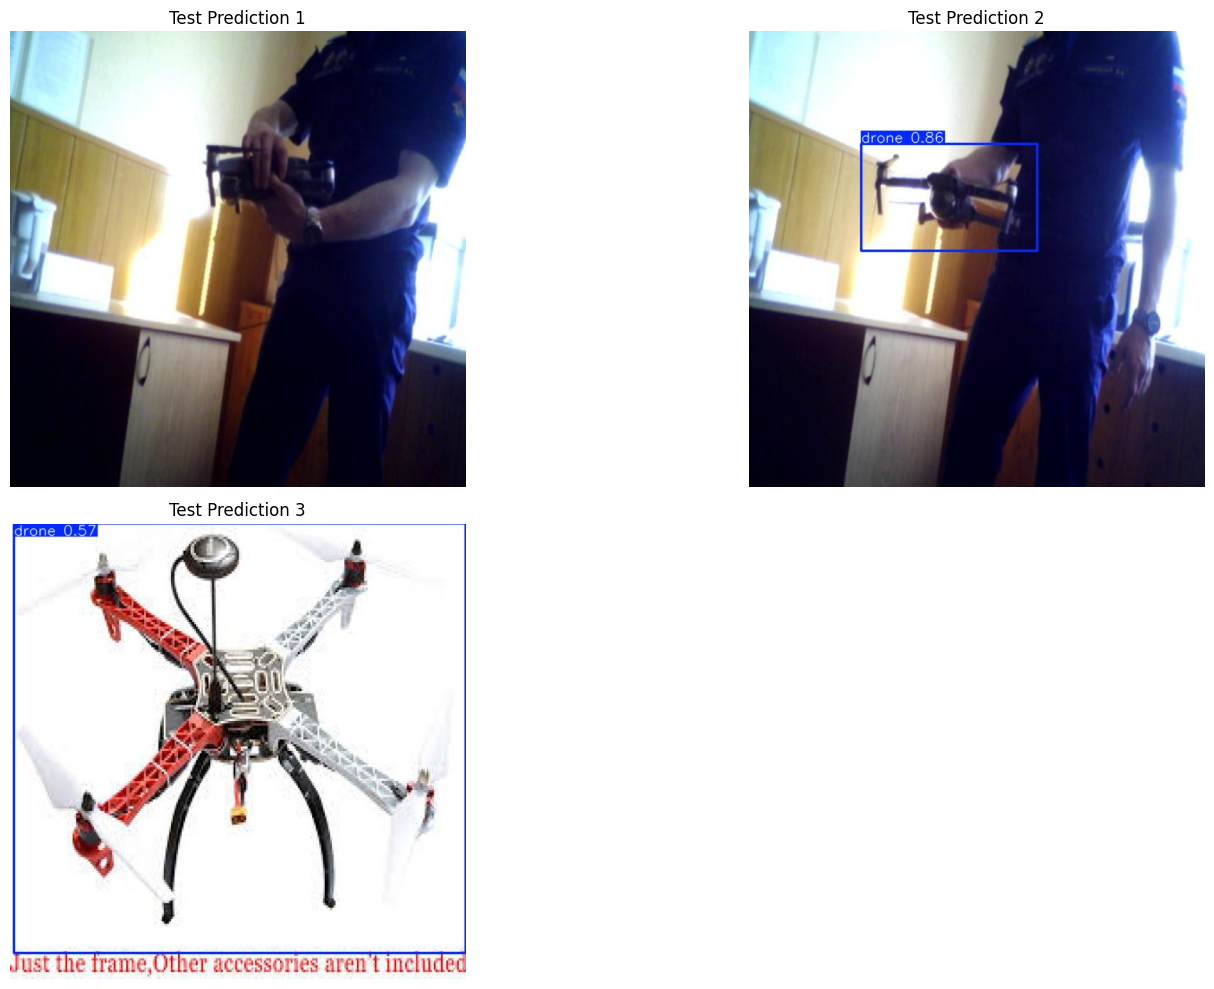

In [ ]:
import glob

# 1. Load your newly trained drone model
best_model_path = '/content/drive/MyDrive/drone_results/drone_detection_v1/weights/best.pt'
if os.path.exists(best_model_path):
    drone_model = YOLO(best_model_path)

    # 2. Run prediction on 4 random test images
    test_img_folder = f'{data_path}/test/images'
    results = drone_model.predict(source=test_img_folder, save=True, conf=0.5, max_det=5)

    # 3. Find where YOLO saved the 'predict' folder
    predict_dirs = sorted(glob.glob('/content/runs/detect/predict*'))
    latest_predict = predict_dirs[-1]
    predicted_images = glob.glob(f'{latest_predict}/*.jpg')

    # 4. Plot a 2x2 Gallery
    plt.figure(figsize=(16, 10))
    for i in range(min(4, len(predicted_images))):
        plt.subplot(2, 2, i+1)
        img = mpimg.imread(predicted_images[i])
        plt.imshow(img)
        plt.title(f"Test Prediction {i+1}", fontsize=12)
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Model weights not found yet. Keep training!")

In [ ]:
model = /content/drive/MyDrive/drone_results/drone_detection_v1/weights/best.pt

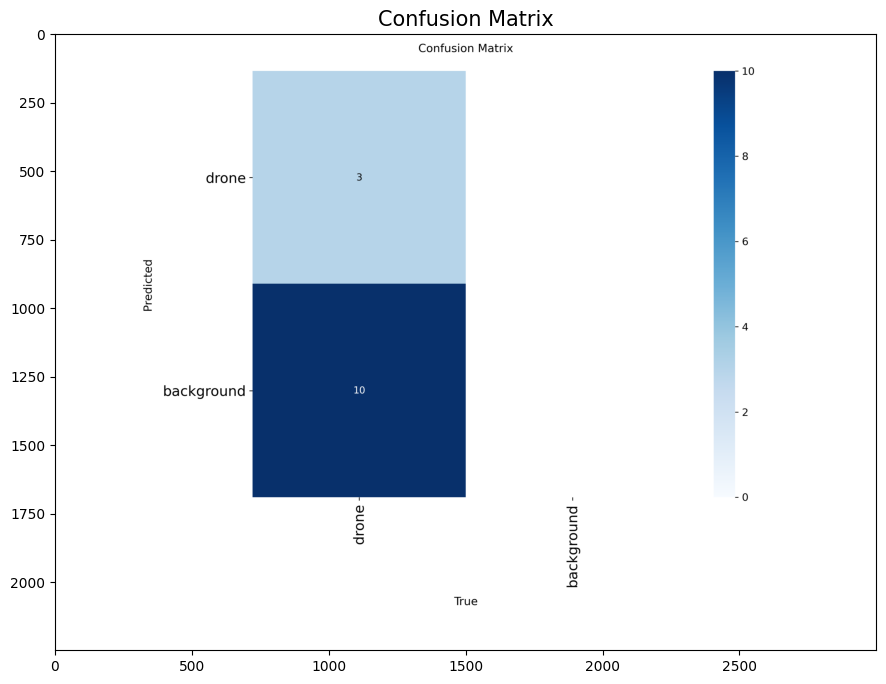

In [ ]:
image = '/content/drive/MyDrive/drone_results26/drone_detection_v1/confusion_matrix.png'

plt.figure(figsize=(12, 8))
plt.imshow(mpimg.imread(image))
plt.title("Confusion Matrix", fontsize=15)
plt.show()

In [ ]:
!yolo model= task=detect ,mode = predict, model = model path to the best model